This notebook contains the steps taken to fine-tune the DistilBERT model.

# Loading dataset

The first step is to load the opinion columns

In [ ]:
import pandas as pd

In [ ]:
df_columns = pd.read_excel("/content/finalized_joined_columns.xlsx")

In [ ]:
df_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 274 non-null    int64 
 1   column_ID                  274 non-null    int64 
 2   Author                     274 non-null    object
 3   Text                       274 non-null    object
 4   Issue                      274 non-null    int64 
 5   Year                       274 non-null    int64 
 6   correspondence_network_ID  46 non-null     object
dtypes: int64(4), object(3)
memory usage: 15.1+ KB


In [ ]:
df_columns.head(5)

,Unnamed: 0,column_ID,Author,Text,Issue,Year,correspondence_network_ID
0,0,0,c_001,"NOW IT'S 1984.\nWelcome to the New Year, 1984....",11,1984,NaN
1,1,1,c_002,"Okay, Timmy Y says I'm a linguist. (My\nmother...",11,1984,U-065
2,2,2,c_003,Of course I realize my columns have lately\nbe...,11,1984,NaN
3,3,3,c_004,ALL WHITE\nAs the dread year is finally upon u...,11,1984,NaN
4,4,4,c_002,Here's a story that made the rounds in\nN.Y. l...,12,1984,NaN


In total there are 274 unique opinion columns, from three different years: 1984, 1989 and 1994.

How many words am I working with?

In [ ]:
import re

df_columns['Text'] = df_columns['Text'].str.replace('\n', ' ', regex=False)

df_columns['Text'] = df_columns['Text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
df_columns['totalwords'] = df_columns['Text'].str.split().str.len()

print(df_columns['totalwords'].sum())

407533


In [ ]:
df_columns.head(5)

,Unnamed: 0,column_ID,Author,Text,Issue,Year,correspondence_network_ID,totalwords
0,0,0,c_001,"NOW IT'S 1984. Welcome to the New Year, 1984. ...",11,1984,NaN,881
1,1,1,c_002,"Okay, Timmy Y says I'm a linguist. (My mother ...",11,1984,U-065,1109
2,2,2,c_003,Of course I realize my columns have lately bee...,11,1984,NaN,1064
3,3,3,c_004,ALL WHITE As the dread year is finally upon us...,11,1984,NaN,583
4,4,4,c_002,Here's a story that made the rounds in N.Y. la...,12,1984,NaN,783


Ok, so a total of 407533 words

Since Transformer models have a max input length of 512 tokens, I will look at the word count distribution.

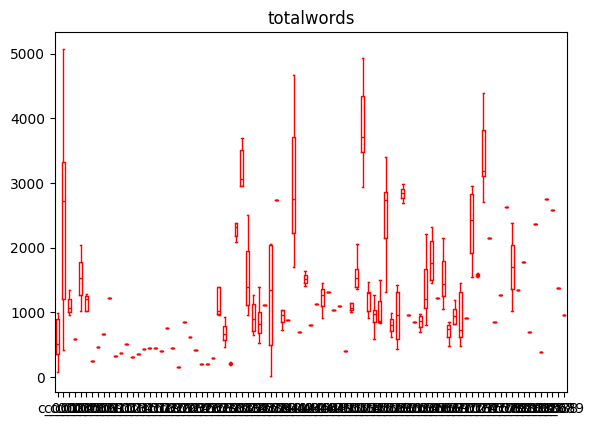

In [ ]:
import matplotlib.pyplot as plt
df_columns.boxplot("totalwords", by = "Author", grid = False, showfliers = False, color = "red")
plt.suptitle("")
plt.xlabel("")
plt.show()

The variation is huge. Some columns have 5k words. I need to keep that in mind, to see if it's something I want to deal with later on.

Importing the letters now

In [ ]:
df_letter = pd.read_excel("/content/finalized_mrr_letters.xlsx")

In [ ]:
df_letter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 697 entries, 0 to 696
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      697 non-null    int64 
 1   index_no        697 non-null    int64 
 2   letter_id       697 non-null    object
 3   letter_content  697 non-null    object
 4   issue           697 non-null    object
 5   Year            697 non-null    int64 
 6   issue_ref       360 non-null    object
 7   issue_num       364 non-null    object
 8   reference_id    378 non-null    object
 9   replies_to      376 non-null    object
 10  Text            697 non-null    object
 11  totalwords      697 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 65.5+ KB


In [ ]:
df_letter.head()

,Unnamed: 0,index_no,letter_id,letter_content,issue,Year,issue_ref,issue_num,reference_id,replies_to,Text,totalwords
0,0,0,L-001,"Hi MRR, \n\nIt was 90° out, the sun wasburning...",MRR_11,1984,NaN,NaN,NaN,NaN,"Hi MRR, It was 90° out, the sun wasburning har...",406
1,1,1,L-002,"Dear Author, \n\nLately I've been hanging thin...",MRR_11,1984,NaN,NaN,NaN,NaN,"Dear Author, Lately I've been hanging things u...",303
2,2,2,L-003,"Dear MRR, \n\nYour last issue was very good. I...",MRR_11,1984,NaN,NaN,NaN,NaN,"Dear MRR, Your last issue was very good. It's ...",624
3,3,3,L-004,"Dear MRR, \n\nIn his review of my band's first...",MRR_11,1984,10,10,"U-004, U0041","column, review","Dear MRR, In his review of my band's first gig...",633
4,4,4,L-005,"Bands who read MRR, \n\nHi, Author here from T...",MRR_11,1984,NaN,NaN,NaN,NaN,"Bands who read MRR, Hi, Author here from TOXIC...",103


In [ ]:
df_letter['Text'] = df_letter['letter_content'].str.replace('\n', ' ', regex=False)

df_letter['Text'] = df_letter['letter_content'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
df_letter['totalwords'] = df_letter['Text'].str.split().str.len()

print(df_letter['totalwords'].sum())

291760


In [ ]:
df_letter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 697 entries, 0 to 696
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      697 non-null    int64 
 1   index_no        697 non-null    int64 
 2   letter_id       697 non-null    object
 3   letter_content  697 non-null    object
 4   issue           697 non-null    object
 5   Year            697 non-null    int64 
 6   issue_ref       360 non-null    object
 7   issue_num       364 non-null    object
 8   reference_id    378 non-null    object
 9   replies_to      376 non-null    object
 10  Text            697 non-null    object
 11  totalwords      697 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 65.5+ KB


In [ ]:
df_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 274 non-null    int64 
 1   column_ID                  274 non-null    int64 
 2   Author                     274 non-null    object
 3   Text                       274 non-null    object
 4   Issue                      274 non-null    int64 
 5   Year                       274 non-null    int64 
 6   correspondence_network_ID  46 non-null     object
 7   totalwords                 274 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 17.3+ KB


Sine I am working with a model from HuggingFace 🤗 I need convert the pandas dataframe into an appropiate format.

In [ ]:
#combining the textual content to fine-tune
df_all = pd.concat([df_letter, df_columns], keys=['letter', 'column'], names=['Source', 'Row_ID']).reset_index()

df_final = df_all[['Text', 'Source']]

In [ ]:
df_final.head()

,Text,Source
0,"Hi MRR, It was 90° out, the sun wasburning har...",letter
1,"Dear Author, Lately I've been hanging things u...",letter
2,"Dear MRR, Your last issue was very good. It's ...",letter
3,"Dear MRR, In his review of my band's first gig...",letter
4,"Bands who read MRR, Hi, Author here from TOXIC...",letter


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    971 non-null    object
 1   Source  971 non-null    object
dtypes: object(2)
memory usage: 15.3+ KB


In [ ]:
from datasets import Dataset

In [ ]:
hf_dataset = Dataset.from_pandas(df_final)

In [ ]:
display(hf_dataset)

Dataset({
    features: ['Text', 'Source'],
    num_rows: 971
})

# Preprocessing - Tokenizing

The first step is tokenization. I will be borrowing the code from Tunstall et al. (2022) for this step. https://www.oreilly.com/library/view/natural-language-processing/9781098136789/

DistilBERT will be used for this part of my research project. This model achieves comparable performance to its larger cousin BERT, while being smaller. The advantage is that DistilBERT can be trained much quicker.

The opinion columns + letters will now be tokenized and encoded as numerical vectors using the tokenizer for DistilBERT.

In [ ]:
from transformers import DistilBertTokenizer

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#I will now tokenize the whole dataset, first make a function

def tokenize(batch):
  return tokenizer(batch["Text"],
                   padding = "max_length",
                   truncation = True,
                   max_length = 512,
                   return_overflowing_tokens = True,
                   stride = 128) #need to work on this later to account for large columns. edit: has been worked on, good enough now!



By implementing return_overflowing_tokens the model can account for the token limit. It allows for the tokenizer to return tokens that exceed the max length, splitting the text into chunks.

I could experiment with other methods chunking methods... but this should work for now.

In [ ]:
#now map the function accross my dataset with .map

tokenized_dataset = hf_dataset.map(
    tokenize,
    batched = True,
    remove_columns = hf_dataset.column_names #this accounts for the overflowing tokens
)

Map:   0%|          | 0/971 [00:00<?, ? examples/s]

In [ ]:
print(len(tokenized_dataset))

2658


In [ ]:
total_tokens = sum(len(ids) for ids in tokenized_dataset["input_ids"])

print(f"Total Chunks: {len(tokenized_dataset)}")
print(f"Total Tokens: {total_tokens:,}")

Total Chunks: 2658
Total Tokens: 1,360,896


# Fine-Tuning


For this step, I will use masked language modeling (MLM) to fine-tune DistilBERT on my dataset.

Although the article by Xiao and Feng (2025) that inspires my method, does not fine-tune their models I think that for my specific data it is the best way to go about it. Since the purpose of the authors there was just to develop an anomaly detection benchmark, my objectives are slightly different.

MLM is useful for fine-tuning on domain-specific text.


I will use these tutorials as my guide for this stage: https://huggingface.co/docs/transformers/tasks/masked_language_modeling

https://ai.plainenglish.io/fine-tuning-a-masked-language-model-for-domain-specific-understanding-a74b556cc49d


In [ ]:
#check the tokenizer being used

print(tokenizer)

DistilBertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [ ]:
from transformers import AutoModelForMaskedLM

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForMaskedLM.from_pretrained("distilbert-base-uncased")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
from transformers import DataCollatorForLanguageModeling

In [ ]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm_probability=0.15 #15% of the tokens in each sequence will be placed with [MASK] and the model will guess or predict the likely token
)

In [ ]:
split_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=42)

train_ds = split_dataset["train"]
eval_ds = split_dataset["test"]

print(f"Training chunks: {len(train_ds)}")
print(f"Evaluation chunks: {len(eval_ds)}")

Training chunks: 2392
Evaluation chunks: 266


In [ ]:
samples = [tokenized_dataset[i] for i in range(2)]

chunked_check = data_collator(samples)

for chunk in chunked_check["input_ids"]:
    print(f"\n'>>> {tokenizer.decode(chunk)}'")


'>>> [CLS] hi mrr, it was 90° out, the [MASK] [MASK]burning hard, we were all thirsty, but the lines at the water fountains seemed like lines to movie theaters. [MASK] was [MASK] overcrowded, about 5000 people, but [MASK] [MASK] have been thousands more. everyone there was different in their own way [MASK] but they all [MASK] one common interest... peace. all those people want to go on living and want to change what ' s going on in those multi - storied [MASK] nuildings. it was my ' first peace [MASK], but definitely not my [MASK]. i feel [MASK] should take time out of my life to try strasbourg preserve everyones - try to make a better [MASK] to live in. it was my [MASK]. i was surprised to [MASK] a large number [MASK] punks there. some friends of mine brought a banner reading [MASK] punks for peace ", " no nuclear war " with a happy [MASK] [unused219] it, with [MASK] mohawk. they let me march with them apes and many people took pictures and [MASK] us [MASK] [MASK] feel the punk image

Output shows how [MASK] becomes a token that the model will try to predict.

Define the training hyperparamenters.

In [ ]:
from transformers import TrainingArguments

In [ ]:
batch_size = 16

training_args = TrainingArguments(
    output_dir = "distilbert-finetuned-mrr",
    num_train_epochs = 10,
    learning_rate = 2e-5,
    weight_decay = 0.01,
    per_device_train_batch_size = batch_size,

    eval_strategy = "epoch",
    logging_strategy = "steps",
    logging_steps = 50,

    load_best_model_at_end = True,
    save_strategy = "epoch"
)

Initiate the Trainer to wrap everything together

In [ ]:
from transformers import Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.796884,2.700450
2,2.710986,2.598430
3,2.661090,2.562382
4,2.635687,2.579432
5,2.617548,2.571314
6,2.585399,2.535026
7,2.587166,2.505964
8,2.535097,2.517998
9,2.545858,2.545596
10,2.559095,2.535367


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias', 'vocab_projector.weight'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1510, training_loss=2.616226758388494, metrics={'train_runtime': 1925.9131, 'train_samples_per_second': 12.524, 'train_steps_per_second': 0.784, 'total_flos': 3197375085035520.0, 'train_loss': 2.616226758388494, 'epoch': 10.0})

In [ ]:
from huggingface_hub import login
login(token=#"redacted") #remember to redact this!!****

In [ ]:
model_name = "mrr-punk-columns-and-letters-distilbert"

In [ ]:
trainer.push_to_hub(f"limhayi/{model_name}")
tokenizer.push_to_hub(f"limhayi/{model_name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ned-mrr/model.safetensors:   0%|          |  575kB /  268MB            

  ...ned-mrr/training_args.bin:   1%|          |  43.0B / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/limhayi/mrr-punk-columns-and-letters-distilbert/commit/3261f907c0ae6f0765b71f9fafead074e27369bc', commit_message='Upload tokenizer', commit_description='', oid='3261f907c0ae6f0765b71f9fafead074e27369bc', pr_url=None, repo_url=RepoUrl('https://huggingface.co/limhayi/mrr-punk-columns-and-letters-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='limhayi/mrr-punk-columns-and-letters-distilbert'), pr_revision=None, pr_num=None)

In [ ]:
trainer.model.push_to_hub("limhayi/mrr-punk-columns-and-letters-distilbert")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...sf6zqay/model.safetensors:  39%|###8      |  104MB /  268MB            

CommitInfo(commit_url='https://huggingface.co/limhayi/mrr-punk-columns-and-letters-distilbert/commit/fb3c6ec81020ff8a0d7a63b3217289053649eabb', commit_message='Upload DistilBertForMaskedLM', commit_description='', oid='fb3c6ec81020ff8a0d7a63b3217289053649eabb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/limhayi/mrr-punk-columns-and-letters-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='limhayi/mrr-punk-columns-and-letters-distilbert'), pr_revision=None, pr_num=None)

# Playing with the model and its predictions

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoModelForMaskedLM

model_name = "limhayi/mrr-punk-columns-and-letters-distilbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
import torch

test_text = "The genre of this album is [MASK]."

inputs = tokenizer(test_text, return_tensors="pt").to("cuda")
model.to("cuda")

with torch.no_grad():
    token_logits = model(**inputs).logits

mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]
mask_token_logits = token_logits[0, mask_token_index, :]
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

for token in top_5_tokens:
    print(f"'>>> {test_text.replace(tokenizer.mask_token, tokenizer.decode([token]))}'")

'>>> The genre of this album is unknown.'
'>>> The genre of this album is pop.'
'>>> The genre of this album is punk.'
'>>> The genre of this album is rock.'
'>>> The genre of this album is jazz.'


In [ ]:
test_text_2 = "This record is total [MASK], don't waste your money."


In [ ]:
inputs = tokenizer(test_text_2, return_tensors="pt").to("cuda") # add .to("cuda") if using GPU
model.to("cuda")

with torch.no_grad():
    token_logits = model(**inputs).logits

mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]
mask_token_logits = token_logits[0, mask_token_index, :]
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

for token in top_5_tokens:
    print(f"'>>> {test_text_2.replace(tokenizer.mask_token, tokenizer.decode([token]))}'")

'>>> This record is total ##itarian, don't waste your money.'
'>>> This record is total success, don't waste your money.'
'>>> This record is total bullshit, don't waste your money.'
'>>> This record is total shit, don't waste your money.'
'>>> This record is total time, don't waste your money.'


In [ ]:
from transformers import pipeline

punk_brain = pipeline("fill-mask", model=model, tokenizer=tokenizer)

vanilla_brain = pipeline("fill-mask", model="distilbert-base-uncased")

text = "The band played a fast set at the [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

--- FINE-TUNED DISTILBERT PREDICTIONS ---
venue: 0.0854
show: 0.0845
festival: 0.0422
club: 0.0372
arena: 0.0314

--- VANILLA DISTILBERT PREDICTIONS ---
venue: 0.1372
festival: 0.0410
arena: 0.0380
stadium: 0.0296
coliseum: 0.0276


In [ ]:

text = "The scene is being ruined by [MASK] who don't care about the music."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
people: 0.6903
bands: 0.0632
those: 0.0492
musicians: 0.0213
kids: 0.0113

--- VANILLA DISTILBERT PREDICTIONS ---
people: 0.2171
fans: 0.0594
musicians: 0.0476
thugs: 0.0267
those: 0.0216


In [ ]:
text = "people are [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
free: 0.0258
poor: 0.0232
white: 0.0222
here: 0.0182
jewish: 0.0178

--- VANILLA DISTILBERT PREDICTIONS ---
bilingual: 0.0384
farmers: 0.0314
christians: 0.0291
muslim: 0.0225
vegetarian: 0.0192


In [ ]:
text = "cops are [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
here: 0.0762
there: 0.0513
everywhere: 0.0492
involved: 0.0262
dead: 0.0205

--- VANILLA DISTILBERT PREDICTIONS ---
everywhere: 0.0732
here: 0.0301
corrupt: 0.0183
waiting: 0.0167
coming: 0.0165


In [ ]:
text = "politics are not [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
fair: 0.0392
political: 0.0258
free: 0.0250
politics: 0.0209
allowed: 0.0145

--- VANILLA DISTILBERT PREDICTIONS ---
uncommon: 0.0473
partisan: 0.0407
compulsory: 0.0233
regulated: 0.0189
tolerated: 0.0146


In [ ]:
text = "I am writing this column from [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
here: 0.1050
now: 0.0439
there: 0.0197
today: 0.0120
chicago: 0.0118

--- VANILLA DISTILBERT PREDICTIONS ---
here: 0.0616
yesterday: 0.0291
facebook: 0.0236
wikipedia: 0.0236
scratch: 0.0232


In [ ]:
text = "America is not [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
free: 0.0769
ours: 0.0188
racist: 0.0179
alone: 0.0139
socialist: 0.0131

--- VANILLA DISTILBERT PREDICTIONS ---
neutral: 0.0195
divided: 0.0167
free: 0.0161
racist: 0.0127
threatened: 0.0085


In [ ]:
text = "Punk is not [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
punk: 0.0693
acceptable: 0.0259
cool: 0.0249
popular: 0.0214
art: 0.0207

--- VANILLA DISTILBERT PREDICTIONS ---
uncommon: 0.1018
acceptable: 0.0343
discouraged: 0.0320
banned: 0.0313
illegal: 0.0295


In [ ]:
text = "vote for [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
change: 0.0369
equality: 0.0348
peace: 0.0281
democracy: 0.0262
me: 0.0241

--- VANILLA DISTILBERT PREDICTIONS ---
reelection: 0.0294
confidence: 0.0261
equality: 0.0226
independence: 0.0210
democracy: 0.0209


In [ ]:
text = "anarchy is [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

--- FINE-TUNED DISTILBERT PREDICTIONS ---
anarchy: 0.0553
free: 0.0273
rampant: 0.0240
everywhere: 0.0238
not: 0.0225

--- VANILLA DISTILBERT PREDICTIONS ---
rampant: 0.0773
inevitable: 0.0359
forbidden: 0.0356
everywhere: 0.0333
outlawed: 0.0286


In [ ]:
text = "the hardcore scene is [MASK]."

print("--- FINE-TUNED DISTILBERT PREDICTIONS ---")
for res in punk_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

print("\n--- VANILLA DISTILBERT PREDICTIONS ---")
for res in vanilla_brain(text):
    print(f"{res['token_str']}: {res['score']:.4f}")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


--- FINE-TUNED DISTILBERT PREDICTIONS ---
punk: 0.0522
thriving: 0.0444
hardcore: 0.0337
diverse: 0.0266
underground: 0.0227

--- VANILLA DISTILBERT PREDICTIONS ---
sparse: 0.0592
eclectic: 0.0422
lively: 0.0197
hardcore: 0.0185
chaotic: 0.0170
